In [1]:
from e3nn_covLayer import *

## JSON Preprocessing

In [3]:
import json
import random

def format_coordinates(entry):
    """
    Converts 'optimized_coordinates_S0' from a list to a formatted multi-line string.
    """
    if "optimized_coordinates_S0" not in entry:
        return None  # Skip if missing

    if entry.get("optimized_coordinates_S0") is None:
        return None

    raw_lines = entry["optimized_coordinates_S0"]

    # Ensure the first element is the atom count (remove if not numeric)
    try:
        atom_count = int(raw_lines[0])  # Extract number of atoms
        coordinates = raw_lines[1:]  # Skip the atom count line
    except ValueError:
        return None  # Skip if the first element is not an integer

    # Format into desired string with atom count, newline, and indented coordinates
    formatted_str = f"{atom_count}\n\n" + "\n".join(f"    {line}" for line in coordinates)

    return formatted_str

def process_json(input_path, output_path, max_entries=None):
    """
    Reads a JSON file, reformats molecular coordinates, selects a random subset, and saves the new file.

    Parameters:
        input_path (str): Path to the input JSON file.
        output_path (str): Path to save the processed JSON file.
        max_entries (int, optional): Maximum number of entries to keep (randomly selected).
    """
    with open(input_path, 'r') as f:
        data = json.load(f)

    # Process each molecule entry
    processed_data = []
    for entry in data:
        formatted_str = format_coordinates(entry)
        if formatted_str:
            entry["opt_molecule_S0"] = formatted_str  # Add new formatted field
            processed_data.append(entry)

    # Randomly select max_entries if specified
    if max_entries and len(processed_data) > max_entries:
        processed_data = random.sample(processed_data, max_entries)

    # Save updated data
    with open(output_path, 'w') as f:
        json.dump(processed_data, f, indent=4)

    print(f"Processed {len(processed_data)} entries saved to {output_path}")

input_json = "processed_dataset.json"
output_json = "test_dataset.json"
process_json(input_json, output_json, 1000)


Processed 1000 entries saved to test_dataset.json


## EDA


Missing Data Summary:
                             Missing Data  Percentage
homo (eV)                               0         0.0
lumo (eV)                               0         0.0
reduction_potential_S1 (eV)           493        49.3

Summary Statistics (Range, Mean, Std):
         homo (eV)    lumo (eV)  reduction_potential_S1 (eV)
count  1000.000000  1000.000000                   507.000000
mean     -7.029957    -3.902130                     1.515535
std       0.718216     0.280424                     0.525799
min      -8.716079    -4.717366                     0.138873
25%      -7.548507    -4.093341                     1.161632
50%      -7.093464    -3.895310                     1.537201
75%      -6.525154    -3.720341                     1.895320
max      -4.791653    -2.946993                     3.131460


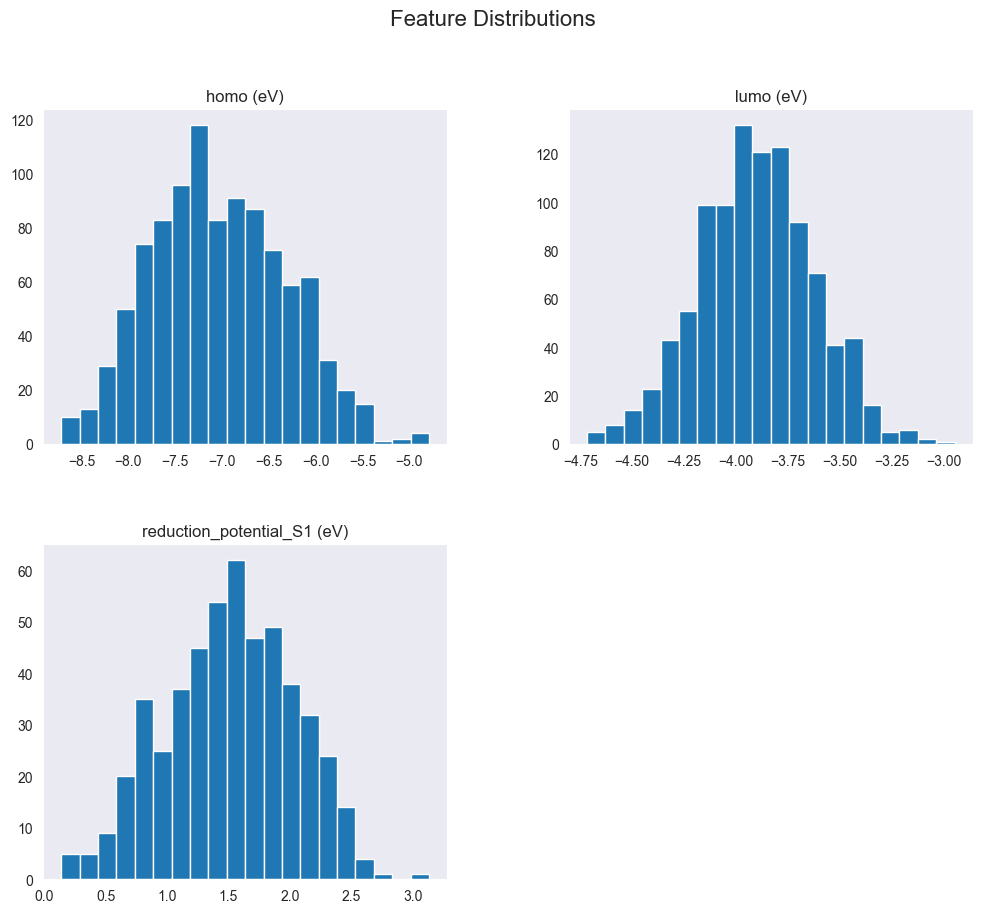

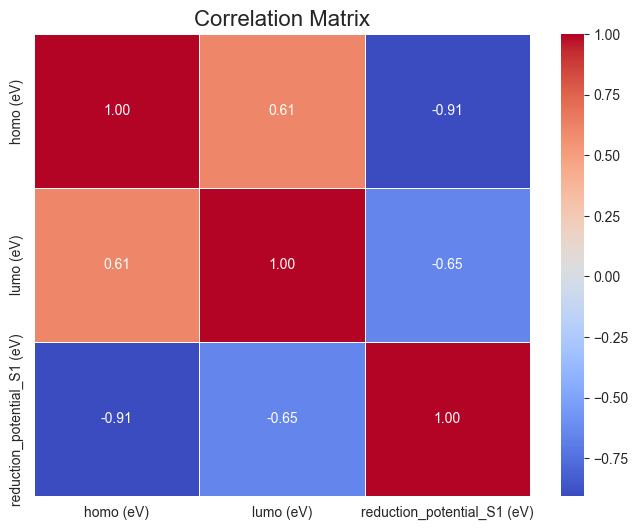

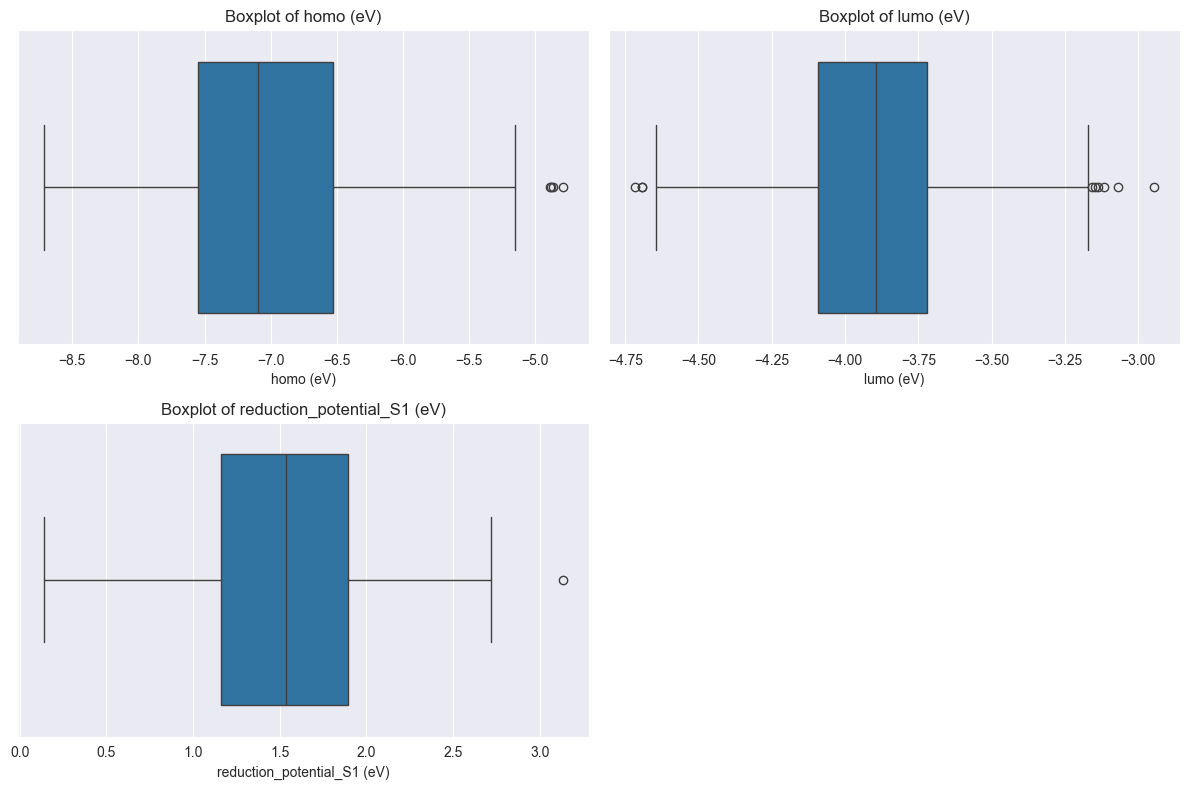

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the features of interest
FEATURES_OF_INTEREST = ['homo (eV)', 'lumo (eV)', 'reduction_potential_S1 (eV)']

def load_json(input_path):
    """
    Loads the JSON data into a Pandas DataFrame.
    """
    with open(input_path, 'r') as f:
        data = json.load(f)

    # Convert list of dictionaries to pandas DataFrame
    df = pd.DataFrame(data)
    return df

def check_missing_data(df):
    """
    Checks for missing data in the DataFrame and prints a summary.
    """
    print("\nMissing Data Summary:")
    missing_data = df[FEATURES_OF_INTEREST].isnull().sum()
    missing_percentage = (df[FEATURES_OF_INTEREST].isnull().sum() / len(df)) * 100
    missing_summary = pd.DataFrame({'Missing Data': missing_data, 'Percentage': missing_percentage})
    print(missing_summary)

def summary_statistics(df):
    """
    Prints summary statistics for numerical features of interest.
    """
    print("\nSummary Statistics (Range, Mean, Std):")
    print(df[FEATURES_OF_INTEREST].describe())

def plot_histograms(df):
    """
    Plots histograms for the selected features.
    """
    df[FEATURES_OF_INTEREST].hist(bins=20, figsize=(12, 10), grid=False)
    plt.suptitle("Feature Distributions", fontsize=16)
    plt.show()

def plot_correlation_matrix(df):
    """
    Plots a correlation heatmap for numerical features.
    """
    # Calculate correlation for numerical features
    correlation = df[FEATURES_OF_INTEREST].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Correlation Matrix", fontsize=16)
    plt.show()

def plot_boxplots(df):
    """
    Plots boxplots to visualize the spread and outliers of numerical features.
    """
    plt.figure(figsize=(12, 8))
    for i, feature in enumerate(FEATURES_OF_INTEREST):
        plt.subplot(2, 2, i+1)
        sns.boxplot(data=df, x=feature)
        plt.title(f"Boxplot of {feature}")
    plt.tight_layout()
    plt.show()

def perform_eda(input_path):
    """
    Perform full exploratory data analysis on the input JSON data.
    """
    # Load data
    df = load_json(input_path)

    # Check missing data
    check_missing_data(df)

    # Summary statistics for numerical columns
    summary_statistics(df)

    # Plot histograms of numerical features
    plot_histograms(df)

    # Plot correlation matrix
    plot_correlation_matrix(df)

    # Plot boxplots for selected features
    plot_boxplots(df)

# Example usage
input_json = 'test_dataset.json'  # Path to your input JSON file
perform_eda(input_json)


## Train Test Split Analysis

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def analyze_train_test_split(dataset):
    """
    Analyzes the composition of the train vs test split with visualizations of HOMO, Reduction Potential,
    and the atomic composition.

    Parameters:
        dataset: The dataset object containing train and test splits.
    """
    # Extract train and test sets
    train_loader = torch.utils.data.DataLoader(dataset.train_dataset, batch_size=1, shuffle=False)
    test_loader = torch.utils.data.DataLoader(dataset.test_dataset, batch_size=1, shuffle=False)

    # Lists to store values
    train_homo = []
    test_homo = []
    train_red_pot = []
    test_red_pot = []
    train_atoms = []
    test_atoms = []

    # Iterate over training set
    for batch in train_loader:
        train_homo.append(batch.homo.cpu().item())  # Assuming HOMO is a single value
        train_red_pot.append(batch.y.cpu().item())  # Reduction potential (target)
        train_atoms.append(batch.atom_features.cpu().numpy())  # One-hot encoded atoms

    # Iterate over test set
    for batch in test_loader:
        test_homo.append(batch.homo.cpu().item())
        test_red_pot.append(batch.y.cpu().item())
        test_atoms.append(batch.atom_features.cpu().numpy())

    # Convert atom feature lists to numpy arrays
    train_atoms = np.array(train_atoms)
    test_atoms = np.array(test_atoms)

    # Aggregate atom counts (assuming one-hot encoding)
    train_atom_counts = np.sum(train_atoms, axis=0)
    test_atom_counts = np.sum(test_atoms, axis=0)

    # Create figure for visualizations
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Plot HOMO distributions
    sns.histplot(train_homo, bins=30, color='blue', label='Train', kde=True, ax=axes[0, 0])
    sns.histplot(test_homo, bins=30, color='red', label='Test', kde=True, ax=axes[0, 0])
    axes[0, 0].set_title("HOMO Distribution in Train vs Test")
    axes[0, 0].set_xlabel("HOMO Energy")
    axes[0, 0].legend()

    # Plot Reduction Potential distributions
    sns.histplot(train_red_pot, bins=30, color='blue', label='Train', kde=True, ax=axes[0, 1])
    sns.histplot(test_red_pot, bins=30, color='red', label='Test', kde=True, ax=axes[0, 1])
    axes[0, 1].set_title("Reduction Potential Distribution in Train vs Test")
    axes[0, 1].set_xlabel("Reduction Potential")
    axes[0, 1].legend()

    # Plot atom composition (bar chart)
    atom_labels = [f"Atom {i}" for i in range(len(train_atom_counts))]  # Replace with actual atom names if available
    x = np.arange(len(atom_labels))

    axes[1, 0].bar(x - 0.2, train_atom_counts, width=0.4, color='blue', label='Train')
    axes[1, 0].bar(x + 0.2, test_atom_counts, width=0.4, color='red', label='Test')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(atom_labels, rotation=45)
    axes[1, 0].set_title("Atom Composition in Train vs Test")
    axes[1, 0].set_ylabel("Count")
    axes[1, 0].legend()

    # Empty subplot for better layout
    axes[1, 1].axis('off')

    # Adjust layout and show plots
    plt.tight_layout()
    plt.show()

# Call the function in main
if __name__ == "__main__":
    analyze_train_test_split(dataset)


NameError: name 'dataset' is not defined